____
# Lagrangian spectra along the trajectories


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
def generate_0_15m_coloc_dataframe(freq_band):

    DT = 12

    # SURFACE
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    )

    comb_list = [base_dic]

    ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    ds0 = ds0.where(ds0.depth == 0, drop=True)
    # distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    # ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    # ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    # ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    # ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

    df0 = ds0.to_dataframe().reset_index().set_index("row_number")

    # DEPTH 15M
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="15",
    )

    comb_list = [
        base_dic,
    ]

    ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    ds15 = ds15.where(ds15.depth == 15, drop=True)
    # distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    # ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    ds15 = ds15.where(ds15.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
    # ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    # ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

    df15 = ds15.to_dataframe().reset_index().set_index("row_number")

    return df0, df15


def filter_traj(
    ds,
    T=20,
    cutoff={
        "HF": [2.2, 70.95],
        "LF": [0.88],
        "inertial": [1.05, 1.75],
        "diurnal": [0.88, 1.05],
        "semidiurnal": [1.9, 2.1],
    },
):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    # coefficients
    dt = 1 / 24 / 6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False

    # filter
    dss = ds.fillna(0)
    for c in cutoff:
        if c == "LF":
            pass_zero = True
        # elif c == 'HF' : pass_zero = 'highpass'
        else:
            pass_zero = False
        for v in ["acce", "accn", "core", "corn", "ggde", "ggdn", "wde", "wdn"]:
            taps = signal.firwin(
                numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True
            )
            dss[c + v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=["datetime"],
            )
            dss[c + v] = xr.DataArray(
                filtfilt(taps, 1, dss[v]),
                dims=["datetime"],
            )

    return dss

# Data : SWOT- 2km fromduacs

In [3]:
df0, df15 = generate_0_15m_coloc_dataframe("")

# Xarray format
D = []


def coloc_dataset(df):
    D = []
    for id_ in df.drifter_id.unique():
        df_ = df[df.drifter_id == id_].drop_duplicates("datetime").set_index("datetime")
        ds_ = df_.to_xarray().sortby("datetime")
        ds_["drifter_id"] = ds_["drifter_id"].values[0]
        ds_ = ds_.set_coords("drifter_id").expand_dims("drifter_id")
        D.append(ds_)
    ds = xr.concat(D, dim="drifter_id")
    ds = ds.interp(
        datetime=pd.date_range(
            ds.datetime.min().values, ds.datetime.max().values, freq="10min"
        )
    )
    return ds


ds0 = coloc_dataset(df0)
ds15 = coloc_dataset(df15)

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


# Spectra 

In [19]:
var = ["acc", "cor", "ggd", "wd"]
from cstes import U
from sstats import tseries as ts

rename_forspectra = {"datetime": "time", "drifter_id": "id"}


def spectrum_ds(
    ds,
    nperseg="10D",
    detrend=False,
    vc=[("acce", "accn"), ("core", "corn"), ("ggde", "ggdn"), ("wde", "wdn")],
):
    ds = ds.rename(rename_forspectra)
    # ds = df.reset_index().set_index(["time", "id"]).to_xarray()
    E = []
    for tup in vc:
        ds_ = ds.fillna(0).ts.spectrum(
            unit="1D", nperseg=nperseg, detrend=detrend, complex=tup
        )
        E.append(ds_)
    return xr.merge(E)


dss0 = spectrum_ds(
    ds0.fillna(0)[[v + "e" for v in var] + [v + "n" for v in var]] / U,
    nperseg="20D",
    detrend=False,
)
dss15 = spectrum_ds(
    ds15.fillna(0)[[v + "e" for v in var] + [v + "n" for v in var]] / U,
    nperseg="20D",
    detrend=False,
)

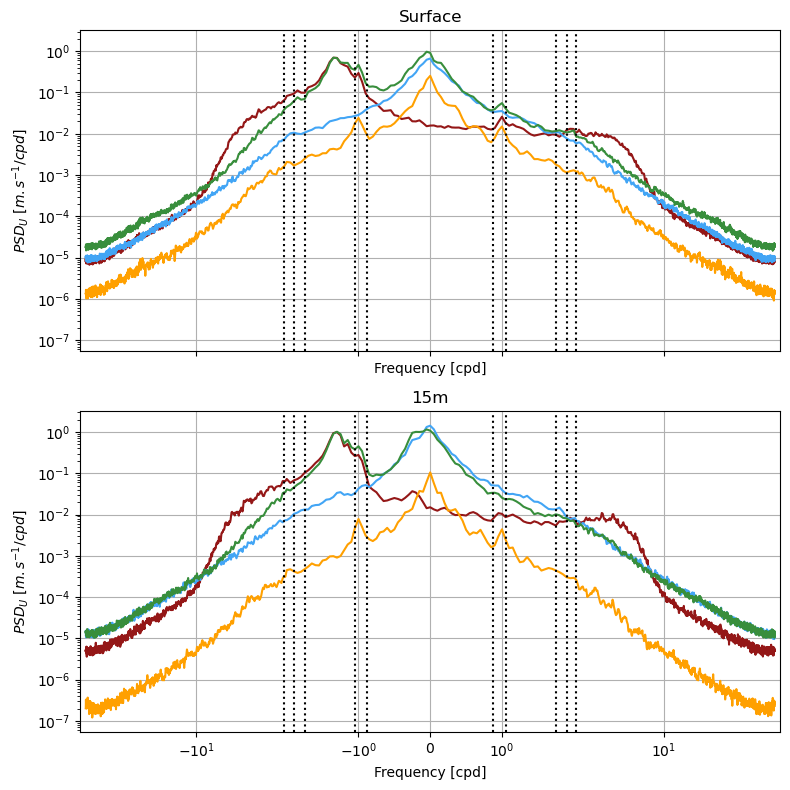

In [20]:
linthresh = 1e-1
linscale = 0.3
fig, axs = plt.subplots(2, 1, figsize=(8, 8), frameon=False, sharex=True, sharey=True)

ax = axs[0]
dss0.acce_accn.mean("id").plot(ax=ax, label="Lagrangian acceleration", c=c0["acc"])
dss0.ggde_ggdn.mean("id").plot(ax=ax, label="Pressure gradient term", c=c0["ggd"])
dss0.core_corn.mean("id").plot(ax=ax, label="Coriolis acceleration", c=c0["cor"])
dss0.wde_wdn.mean("id").plot(ax=ax, label="Wind term", c=c0["wd"])

for f in [0.88, 1.05, 1.75, 1.9, 2.1] + list(-np.array([0.88, 1.05, 1.75, 1.9, 2.1])):
    ax.axvline(f, ls=":", c="k")
ax.set_title("Surface")


ax = axs[1]
dss15.acce_accn.mean("id").plot(ax=ax, label="Lagrangian acceleration", c=c0["acc"])
dss15.ggde_ggdn.mean("id").plot(ax=ax, label="Pressure gradient term", c=c0["ggd"])
dss15.core_corn.mean("id").plot(ax=ax, label="Coriolis acceleration", c=c0["cor"])
dss15.wde_wdn.mean("id").plot(ax=ax, label="Wind term", c=c0["wd"])
ax.set_title("15m")
for f in [0.88, 1.05, 1.75, 1.9, 2.1] + list(-np.array([0.88, 1.05, 1.75, 1.9, 2.1])):
    ax.axvline(f, ls=":", c="k")


for ax in axs:
    ax.set_xscale("symlog")  # , linthresh=linthresh, linscale=linscale)
    ax.set_yscale("log")
    ax.grid()
    ax.set_ylabel(r"$PSD_U$ $[m.s^{-1}/cpd]$")
    ax.set_xlabel("Frequency [cpd]")

fig.tight_layout()

In [21]:
def negpos_spectra(ds, freqkey="frequency"):
    """Return two datasets with cyclonic/anticyclonic spectra"""
    ds_inv = ds.sortby(freqkey, ascending=False)
    dsneg = ds_inv.where(ds_inv[freqkey] <= 0, drop=True)
    dsneg[freqkey] = -dsneg[freqkey]
    dspos = ds.where(ds[freqkey] >= 0, drop=True)
    return dsneg, dspos


dss0 = sum(negpos_spectra(dss0, freqkey="frequency"))
dss15 = sum(negpos_spectra(dss15, freqkey="frequency"))

dss0 = dss0.sel(frequency=slice(0, 10))
dss15 = dss15.sel(frequency=slice(0, 10))

/dev/shm/pbs.4361295.datarmor0/ipykernel_35687/962291502.py:64: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10)


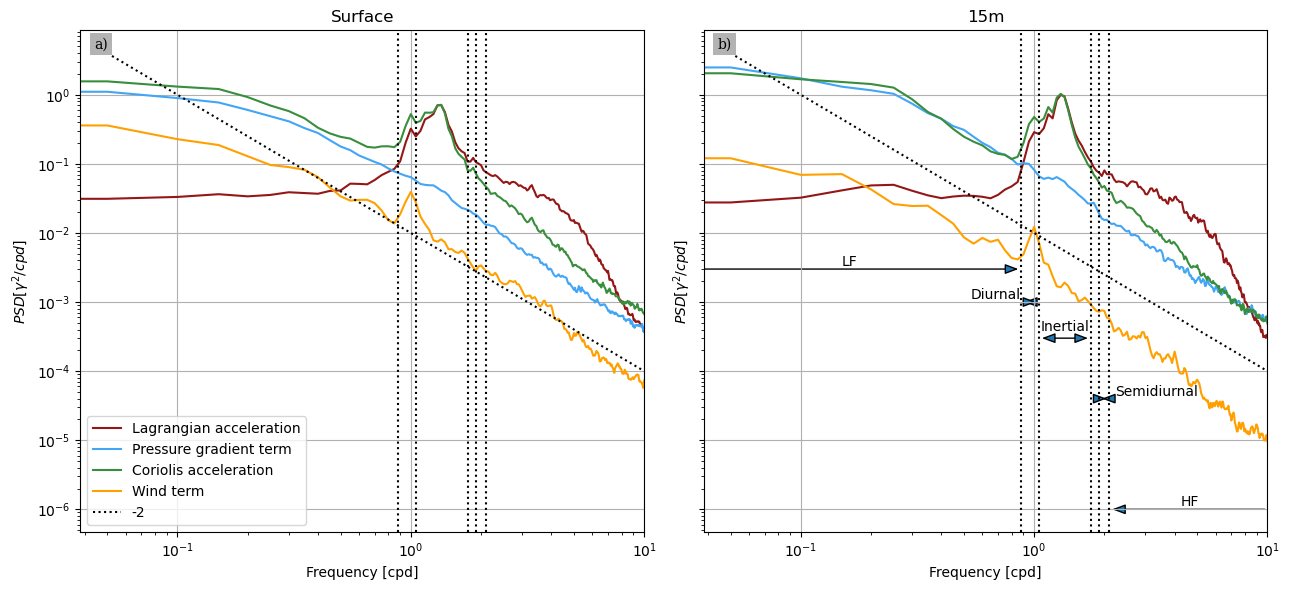

In [48]:
linthresh = 1e-1
linscale = 0.3
fig, axs = plt.subplots(1, 2, figsize=(13, 6), frameon=False, sharex=True, sharey=True)

i = 0
for dss in [dss0, dss15]:
    ax = axs[i]
    dss.acce_accn.mean("id").plot(ax=ax, label="Lagrangian acceleration", c=c0["acc"])
    dss.ggde_ggdn.mean("id").plot(ax=ax, label="Pressure gradient term", c=c0["ggd"])
    dss.core_corn.mean("id").plot(ax=ax, label="Coriolis acceleration", c=c0["cor"])
    dss.wde_wdn.mean("id").plot(ax=ax, label="Wind term", c=c0["wd"])
    ax.plot(dss.frequency, dss.frequency ** (-2) * 1e-2, ls=":", c="k", label="-2")
    i += 1

    for f in [0.88, 1.05, 1.75, 1.9, 2.1]:
        ax.axvline(f, ls=":", c="k")

ax = axs[1]
import matplotlib.patches as mpatches

arr = mpatches.FancyArrowPatch(
    (3e-2, 3e-3), (0.88, 3e-3), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("LF", (0.5, 0.5), xycoords=arr, ha="center", va="bottom")


arr = mpatches.FancyArrowPatch(
    (0.88, 1e-3), (1.05, 1e-3), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Diurnal", (-0.2, 0.5), xycoords=arr, ha="right", va="bottom")

arr = mpatches.FancyArrowPatch(
    (1.05, 3e-4), (1.75, 3e-4), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Inertial", (0.5, 1), xycoords=arr, ha="center", va="bottom")

arr = mpatches.FancyArrowPatch(
    (1.9, 4e-5), (2.1, 4e-5), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Semidiurnal", (1, 0.5), xycoords=arr, ha="left", va="bottom")

arr = mpatches.FancyArrowPatch(
    (2.1, 1e-6), (1e1, 1e-6), arrowstyle="<|-,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("HF", (0.5, 0.5), xycoords=arr, ha="center", va="bottom")




axs[0].set_title("Surface")
axs[1].set_title("15m")

for ax in axs:
    ax.set_ylabel(r"$PSD [\gamma^2/cpd]$")
    ax.set_xlabel("Frequency [cpd]")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid()
    ax.set_xlim(0, 10)
axs[0].legend(loc="lower left")
put_fig_letter(fig, axs[0], "a")
put_fig_letter(fig, axs[1], "b")


fig.tight_layout()

In [14]:
ax = axs[1]
import matplotlib.patches as mpatches

arr = mpatches.FancyArrowPatch(
    (3e-2, 1e-3), (0.88, 1e-3), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("LF", (0.5, 0.5), xycoords=arr, ha="center", va="bottom")
arr = mpatches.FancyArrowPatch(
    (0.88, 1e-4), (1.05, 1e-4), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Diurnal", (0.1, 0.5), xycoords=arr, ha="right", va="bottom")

arr = mpatches.FancyArrowPatch(
    (1.05, 1e-5), (1.75, 1e-5), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Inertial", (-1, 0.5), xycoords=arr, ha="right", va="bottom")

arr = mpatches.FancyArrowPatch(
    (1.9, 1e-6), (2.1, 1e-6), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("Semidiurnal", (1, 0.5), xycoords=arr, ha="left", va="bottom")

arr = mpatches.FancyArrowPatch(
    (2.1, 1e-7), (1e1, 1e-7), arrowstyle="<|-|>,head_width=.15", mutation_scale=20
)
ax.add_patch(arr)
ax.annotate("HF", (0.5, 0.5), xycoords=arr, ha="center", va="bottom")

<xarray.DataArray 'core_corn' (frequency: 1440)> Size: 12kB
array([1.82438168e+00, 1.56190121e+00, 1.31111813e+00, ...,
       3.59244290e-05, 3.59713124e-05, 3.68381184e-05])
Coordinates:
  * frequency  (frequency) float64 12kB -0.0 0.05 0.1 0.15 ... 71.85 71.9 71.95